In [1]:

import os
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
import os




/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH="../../transactions/card_transaction.v1.csv"
df = pd.read_csv(DATA_PATH)

In [3]:

df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True).astype(float)

df["Hour"] = pd.to_datetime(df["Time"], errors="coerce").dt.hour

df["Use Chip"] = df["Use Chip"].map({
    "Online Transaction": 0,
    "Chip Transaction": 1,
    "Swipe Transaction": 2
})

df["Errors?"] = (df["Errors?"] != "None").astype(int)

df["Zip"] = pd.to_numeric(df["Zip"], errors="coerce")

df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

df["Hour"] = (df["Time"] // 3600) % 24
df["Is Fraud?"] = df["Is Fraud?"].map({"Yes": 1, "No": 0})

df = df.fillna(0)

# print(df.dtypes)
# print(df.head())

/tmp/ipykernel_8353/982232121.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"], errors="coerce").dt.hour


In [4]:
df["Merchant City"] = df["Merchant City"].astype(str)
df["Merchant State"] = df["Merchant State"].astype(str)

In [5]:
print(df.dtypes)
print(df.head())

User                int64
Card                int64
Year                int64
Month               int64
Day                 int64
Time              float64
Amount            float64
Use Chip            int64
Merchant Name       int64
Merchant City      object
Merchant State     object
Zip               float64
MCC                 int64
Errors?             int64
Is Fraud?           int64
Hour              float64
dtype: object
   User  Card  Year  Month  Day  Time  Amount  Use Chip        Merchant Name  \
0     0     0  2002      9    1   0.0  134.09         2  3527213246127876953   
1     0     0  2002      9    1   0.0   38.48         2  -727612092139916043   
2     0     0  2002      9    2   0.0  120.34         2  -727612092139916043   
3     0     0  2002      9    2   0.0  128.95         2  3414527459579106770   
4     0     0  2002      9    3   0.0  104.71         2  5817218446178736267   

   Merchant City Merchant State      Zip   MCC  Errors?  Is Fraud?  Hour  
0       La Ver

## Run form here

In [6]:

from dotenv import load_dotenv
import os
import google.generativeai as genai

load_dotenv()

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/tmp/ipykernel_8353/2009901296.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [7]:
for m in genai.list_models():
    print(m.name, "->", m.supported_generation_methods)

models/gemini-2.5-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts -> ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts -> ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it -> ['generateContent', 'countTokens']
models/gemma-3-4b-it -> ['generateContent', 'countTokens']
models/gemma-3-12b-it -> ['generateContent

In [8]:
model_llm = genai.GenerativeModel("models/gemini-flash-latest")

In [9]:
PROMPT = """
==============================
DATA SUMMARY
==============================

- Number of users: 2000
- Transactions span: multiple years (1991–2020)
- Amount has high variability (~100K unique values)
- Merchant Name is high-cardinality (~100K unique)
- Merchant City is high-cardinality (~13K)
- Merchant State includes global locations (223 unique)
- Errors column contains multiple error types (including combinations)
- Fraud label is binary (Yes/No)

==============================
VALUE DISTRIBUTION INSIGHTS
==============================

Use Chip:
- Swipe Transaction
- Online Transaction
- Chip Transaction

Errors?:
- NaN (no error)
- Technical Glitch
- Insufficient Balance
- Bad PIN
- Bad CVV
- Bad Zipcode
- Combinations of above errors

Merchant State:
- Mix of US states and international locations

Is Fraud:
- Yes / No

==============================
SAMPLE DATA (STRUCTURE)
==============================

Each row represents a transaction:

User=0, Card=0, Year=2002, Month=9, Day=1, Time=06:21,
Amount=$134.09, Use Chip=Swipe Transaction,
Merchant Name=high-cardinality ID,
Merchant City=La Verne, Merchant State=CA,
Zip=91750, MCC=5300, Errors?=NaN, Is Fraud=No

==============================
PREPROCESSING & MISSING VALUE HANDLING
==============================

Before feature computation, assume the following preprocessing has been applied:

1. Amount:
   - Remove "$" and convert to float
   - Missing values (if any) → fill with median Amount

2. Time:
   - Convert "HH:MM" → Hour (0–23)
   - Missing values → fill with mode Hour

3. Use Chip:
   - Encode as:
       Swipe Transaction → 0
       Chip Transaction → 1
       Online Transaction → 2
   - Missing values → fill with most frequent category

4. Errors?:
   - NaN → 0 (no error)
   - Any error string → 1 (error present)

5. Merchant City / Merchant State:
   - Missing values → fill with "Unknown"

6. Zip:
   - Missing values → fill with median Zip

7. MCC:
   - Missing values → fill with mode MCC

8. Is Fraud:
   - Yes → 1, No → 0
   - MUST NOT be used for feature generation

After preprocessing, the following cleaned columns are available:

- Amount (float)
- Hour (int)
- Use Chip (int)
- Errors? (int)
- MCC (int)
- Merchant City (string)
- Merchant State (string)
- Zip (float)


==============================
IMPORTANT DATA CHARACTERISTICS
==============================

- Merchant Name is extremely high-cardinality → avoid direct usage
- Merchant City/State have high diversity → use aggregation (nunique)
- Time is granular → useful for behavioral patterns
- Errors column contains multiple combined error types
- Amount has high variance → useful for anomaly detection



============================== 
YOUR TASK 
============================== 
Design USER-LEVEL features for fraud detection. Each feature MUST produce ONE value per User.

==============================
OUTPUT FORMAT (STRICT JSON)
==============================

Return a JSON list:

[
  {
    "feature_name": "...",
    "pandas_code": "...",
    "description": "...",
    "intuition": "...",
    "type": "numeric"
  }
]

- pandas_code must be executable
- must return a Series indexed by User
- no explanations outside JSON

==============================
EXECUTION REQUIREMENTS
==============================

- Features must be computed using pandas
- Final output must be a Series indexed by User
- Length must equal number of unique users
- Must not use undefined variables
- Must not use target column (Is Fraud)

==============================
ALLOWED OPERATIONS
==============================

You may use:

- multiple aggregations
- ratios (e.g., sum / count)
- differences (max - mean)
- standard deviation and variance
- conditional aggregations
- arithmetic combinations of features

==============================
QUALITY CONSTRAINTS
==============================

- Avoid redundant or highly correlated features
- Prefer interpretable features
- Prefer features that capture behavioral differences
- Avoid trivial features (e.g., constant or near-constant)

==============================
FINAL INSTRUCTIONS
==============================

- Generate 40–50 features
- Each feature must be unique and meaningful
- Output ONLY JSON
- Do NOT include explanations outside JSON

Ensure final output remains a valid Series per User.
"""

In [10]:
# response = call_llm(PROMPT)

response = model_llm.generate_content(PROMPT)
print("RAW OUTPUT:\n", response)

RAW OUTPUT:
 response:
GenerateContentResponse(
    done=True,
    iterator=None,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "[\n  {\n    \"feature_name\": \"user_avg_transaction_amount\",\n    \"pandas_code\": \"df.groupby('User')['Amount'].mean()\",\n    \"description\": \"Average transaction amount per user.\",\n    \"intuition\": \"Baseline spending behavior; significant deviations from this might indicate fraud.\",\n    \"type\": \"numeric\"\n  },\n  {\n    \"feature_name\": \"user_max_transaction_amount\",\n    \"pandas_code\": \"df.groupby('User')['Amount'].max()\",\n    \"description\": \"Maximum transaction amount ever recorded for the user.\",\n    \"intuition\": \"Fraudulent transactions often involve unusually high amounts compared to historical peaks.\",\n    \"type\": \"numeric\"\n  },\n  {\n    \"feature_name\": \"user_std_transaction_amount\",\n    \"pa

In [11]:
# response = model_llm.generate_content(PROMPT)

output = response.text
# print("Raw Output:\n", output)

output = output.replace("```json", "").replace("```", "").strip()

features = json.loads(output)

user_df = pd.DataFrame()

for f in features:
    try:
        print("Applying:", f["feature_name"])
        user_df[f["feature_name"]] = eval(f["pandas_code"])
    except Exception as e:
        print("Error in", f["feature_name"], ":", e)

# Add label
user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

# Fill missing
user_df = user_df.fillna(0)

print("\nFinal Shape:", user_df.shape)
print(user_df.head())

Applying: user_avg_transaction_amount
Applying: user_max_transaction_amount
Applying: user_std_transaction_amount
Applying: user_total_spend
Applying: user_transaction_count
Applying: user_unique_card_count
Applying: user_online_transaction_ratio
Applying: user_swipe_transaction_ratio
Applying: user_chip_transaction_ratio
Applying: user_error_rate
Applying: user_unique_mcc_count
Applying: user_unique_city_count
Applying: user_unique_state_count
Applying: user_night_transaction_ratio
Applying: user_evening_transaction_ratio
Applying: user_avg_hour
Applying: user_std_hour
Applying: user_amount_range
Applying: user_cv_amount
Applying: user_high_value_tx_ratio
Applying: user_small_value_tx_ratio
Applying: user_mcc_diversity_index
Applying: user_city_diversity_index
Applying: user_tx_per_card
Applying: user_active_year_count
Applying: user_tx_per_year
Applying: user_total_errors
Applying: user_iqr_amount
Applying: user_90th_percentile_amount
Applying: user_skew_amount
Applying: user_round_a

<string>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Applying: user_avg_mccs_per_card


<string>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Applying: user_avg_day_of_month
Applying: user_std_day_of_month
Applying: user_tx_intensity_index
Applying: user_non_error_amount_mean
Applying: user_morning_transaction_ratio
Applying: user_afternoon_transaction_ratio
Applying: user_kurtosis_amount
Applying: user_median_absolute_deviation_amount
Applying: user_max_minus_median_amount

Final Shape: (2000, 51)
      user_avg_transaction_amount  user_max_transaction_amount  \
User                                                             
0                       81.299989                      1409.40   
1                       81.118050                      3750.60   
2                       35.159687                      1195.57   
3                      117.277603                      6820.20   
4                       97.011698                      3613.22   

      user_std_transaction_amount  user_total_spend  user_transaction_count  \
User                                                                          
0                

In [12]:
print("\nFinal Shape:", user_df.shape)
print(user_df.head())


Final Shape: (2000, 51)
      user_avg_transaction_amount  user_max_transaction_amount  \
User                                                             
0                       81.299989                      1409.40   
1                       81.118050                      3750.60   
2                       35.159687                      1195.57   
3                      117.277603                      6820.20   
4                       97.011698                      3613.22   

      user_std_transaction_amount  user_total_spend  user_transaction_count  \
User                                                                          
0                       94.159093        1622991.69                   19963   
1                      156.784691         723491.89                    8919   
2                       54.298552        1475933.36                   41978   
3                      268.654472        1186497.51                   10117   
4                      138.619564     

In [13]:
user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

In [14]:
print(user_df.shape)

(2000, 51)


In [15]:
def clean_features(X):

    # Replace inf values
    X = X.replace([float("inf"), float("-inf")], float("nan"))

    # Replace very large values (overflow protection)
    X = X.clip(lower=-1e10, upper=1e10)

    # Fill NaNs (important!)
    X = X.fillna(0)

    return X

In [16]:
# Separate label first
y = user_df["is_fraud_user"]

# Remove non-numeric features
X = user_df.drop(columns=["is_fraud_user"])
X = clean_features(X)
X = X.select_dtypes(include=["number"])

In [17]:
print(y.isna().sum())

0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"   
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.87      0.71      0.78       131
           1       0.87      0.95      0.91       269

    accuracy                           0.87       400
   macro avg       0.87      0.83      0.84       400
weighted avg       0.87      0.87      0.87       400

ROC-AUC: 0.9199182723686824


In [21]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

user_active_year_count                   0.122540
user_total_errors                        0.091061
user_transaction_count                   0.085007
user_mcc_diversity_index                 0.064560
user_unique_mcc_count                    0.051499
user_error_amount_sum                    0.047937
user_total_spend                         0.047826
user_tx_per_card                         0.045993
user_zip_nunique                         0.039734
user_unique_state_count                  0.035150
user_avg_mccs_per_card                   0.032245
user_tx_intensity_index                  0.031380
user_unique_city_count                   0.024050
user_online_transaction_ratio            0.019756
user_chip_transaction_ratio              0.018226
user_unique_card_count                   0.017205
user_amount_range                        0.013209
user_tx_per_year                         0.012401
user_max_to_mean_ratio                   0.012327
user_std_day_of_month                    0.011802


In [22]:
feature_names = [f["feature_name"] for f in features]

In [23]:
importance = importance.to_dict()

In [24]:
report1 = classification_report(y_test, y_pred)
roc1 = roc_auc_score(y_test, y_prob)

results= {
    "existing_features": feature_names,
    "classification_report": report1,
    "roc_auc": roc1,
    "importance": importance
}
with open("results_1.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved to results_1.json")

Saved to results_1.json


In [25]:
print(report1)
print(importance)
print(roc1)

              precision    recall  f1-score   support

           0       0.87      0.71      0.78       131
           1       0.87      0.95      0.91       269

    accuracy                           0.87       400
   macro avg       0.87      0.83      0.84       400
weighted avg       0.87      0.87      0.87       400

{'user_active_year_count': 0.12253976973289857, 'user_total_errors': 0.09106135734010701, 'user_transaction_count': 0.08500676792413658, 'user_mcc_diversity_index': 0.06456044521100052, 'user_unique_mcc_count': 0.05149923412665101, 'user_error_amount_sum': 0.04793705821316258, 'user_total_spend': 0.04782643485346973, 'user_tx_per_card': 0.04599303006437562, 'user_zip_nunique': 0.03973439047052923, 'user_unique_state_count': 0.035149532797819676, 'user_avg_mccs_per_card': 0.03224470748132466, 'user_tx_intensity_index': 0.0313799937111782, 'user_unique_city_count': 0.02405005720859152, 'user_online_transaction_ratio': 0.019755753430690384, 'user_chip_transaction_rati

In [26]:
sample = df.sample(n=5, random_state=42)
print(sample)
sample_str = sample.to_string(index=False)

          User  Card  Year  Month  Day  Time  Amount  Use Chip  \
18199893  1470     0  2019      7   10   0.0   59.18         1   
9731325    822     1  2019      1   14   0.0  280.91         0   
536687      41     3  2010      3   15   0.0 -144.00         2   
13223840  1084     0  2015      9   20   0.0    6.76         1   
17070521  1384     0  2014     10   12   0.0    9.17         2   

                Merchant Name Merchant City Merchant State      Zip   MCC  \
18199893 -6853385250336487907       Harwood             MD  20776.0  5813   
9731325   4241336128694185533        ONLINE              0      0.0  4814   
536687     190253443608377572         Hemet             CA  92543.0  3359   
13223840 -7837310524365334241     Littleton             CO  80122.0  5300   
17070521 -5023497618971072366       Gardner             KS  66030.0  5812   

          Errors?  Is Fraud?  Hour  
18199893        1          0   0.0  
9731325         1          0   0.0  
536687          1          0 

In [27]:
def get_prompt(llm_input, df):
    sample = df.sample(n=5, random_state=42)
    sample_str = sample.to_string(index=False)

    PROMPT = f"""
You are a fraud analytics feature engineering expert.

A RandomForestClassifier was trained on USER-LEVEL features.

Your goal is to IMPROVE feature quality based on previous model performance.

==============================
DATA SAMPLE (RANDOM)
==============================
{sample_str}

==============================
MODEL PERFORMANCE
==============================

Classification Report:
{llm_input["classification_report"]}

ROC-AUC:
{llm_input["roc_auc"]}

Top Important Features:
{llm_input["importance"]}

==============================
DATA SUMMARY
==============================

- Number of users: 2000
- Transactions span: multiple years (1991–2020)
- Amount has high variability (~100K unique values)
- Merchant Name is high-cardinality (~100K unique) → DO NOT USE
- Merchant City is high-cardinality (~13K)
- Merchant State includes global locations (223 unique)
- Errors column contains multiple error types (including combinations)
- Fraud label is binary (Yes/No)

==============================
VALUE DISTRIBUTION INSIGHTS
==============================

Use Chip:
- Swipe Transaction
- Online Transaction
- Chip Transaction

Errors?:
- NaN (no error)
- Technical Glitch
- Insufficient Balance
- Bad PIN
- Bad CVV
- Bad Zipcode
- Combinations of above errors

Merchant State:
- Mix of US states and international locations

Is Fraud:
- Yes / No

==============================
PREPROCESSING ASSUMPTIONS
==============================

Assume the following preprocessing has already been applied:

- Amount → float
- Time → Hour (0–23)
- Use Chip → encoded (0/1/2)
- Errors? → binary (0 = no error, 1 = error)
- Is Fraud → binary (DO NOT USE)

Available columns:

User, Card, Year, Month, Day, Hour, Amount,
Use Chip, Merchant City, Merchant State,
Zip, MCC, Errors?

==============================
CRITICAL GOAL
==============================

Generate USER-LEVEL behavioral features.

Each feature MUST produce:
EXACTLY ONE VALUE PER USER

==============================
YOUR TASK
==============================

1. Analyze model performance:
   - Identify weaknesses (especially fraud recall)
   - Identify missing behavioral signals

2. Improve feature space:
   - Generate NEW features
   - Avoid duplicating existing top features

3. Focus on features that increase discrimination between fraud and non-fraud users

4. Retain features that collectively contribute to approximately 80% of the total feature importance (based on cumulative importance), while ensuring that features contributing to fraud recall are not removed. Remove features with consistently zero importance across iterations, and avoid eliminating features that may contribute through interactions.

==============================
FEATURE DESIGN FOCUS
==============================

- abnormal spending patterns
- spending variability (std, max, min)
- transaction frequency / bursts
- merchant/category diversity
- geographic spread
- temporal irregularity (Hour patterns)
- error behavior
- chip vs swipe usage
- anomaly detection signals

==============================
ALLOWED OPERATIONS
==============================

You MAY use:

- multiple aggregations
- ratios (e.g., sum / count)
- differences (max - mean)
- standard deviation
- conditional aggregations
- arithmetic combinations

==============================
STRICT CODE RULES
==============================

- All code must use dataframe 'df'
- All computations must be based on df.groupby('User')
- Output must be a pandas Series indexed by User
- Do NOT use .values or numpy conversion
- Do NOT reset index
- Do NOT use apply()
- Do NOT use Merchant Name
- Do NOT use target column (Is Fraud)
- Ensure safe operations (avoid division by zero)
- Write code as a single expression (no intermediate variables)

==============================
QUALITY CONSTRAINTS
==============================

- Avoid redundant features
- Avoid highly correlated features
- Prefer interpretable features
- Prefer features capturing behavioral differences
- Avoid trivial features
- Replace or improve weak/low-importance patterns


==============================
OUTPUT FORMAT (STRICT JSON)
==============================

[
  {{
    "feature_name": "...",
    "pandas_code": "...",
    "reason": "Why this feature improves fraud detection"
  }}
]

==============================
FINAL INSTRUCTIONS
==============================

- Generate 15–25 high-quality features
- Each feature must be unique and meaningful
- Every pandas_code must be executable
- Output ONLY JSON
- Do NOT include explanations outside JSON

"""
    return PROMPT

In [28]:
def get_prompt(llm_input, df):
    sample = df.sample(n=5, random_state=42)
    sample_str = sample.to_string(index=False)

    PROMPT = f"""
You are a fraud analytics feature engineering expert.

A RandomForestClassifier was trained on USER-LEVEL features.

Your goal is to IMPROVE feature quality based on previous model performance.

==============================
DATA SAMPLE (RANDOM)
==============================
{sample_str}

==============================
MODEL PERFORMANCE
==============================

Classification Report:
{llm_input["classification_report"]}

ROC-AUC:
{llm_input["roc_auc"]}

Top Important Features:
{llm_input["importance"]}

==============================
FEATURE SELECTION CONSTRAINT (STRICT)
==============================

Top 80% cumulative importance features (MUST RETAIN CONTEXT — DO NOT RECREATE):
{llm_input.get("top_80_features", [])}

Zero importance features (DO NOT USE OR RECREATE):
{llm_input.get("zero_features", [])}

Rules:
- DO NOT recreate or duplicate top 80% features
- DO NOT create variations of zero-importance features
- New features MUST add NEW behavioral signals
- Features should COMPLEMENT existing important ones
- Focus especially on improving FRAUD RECALL (reducing false negatives)

==============================
DATA SUMMARY
==============================

- Number of users: 2000
- Transactions span: multiple years (1991–2020)
- Amount has high variability (~100K unique values)
- Merchant Name is high-cardinality (~100K unique) → DO NOT USE
- Merchant City is high-cardinality (~13K)
- Merchant State includes global locations (223 unique)
- Errors column contains multiple error types (including combinations)
- Fraud label is binary (Yes/No)

==============================
VALUE DISTRIBUTION INSIGHTS
==============================

Use Chip:
- Swipe Transaction
- Online Transaction
- Chip Transaction

Errors?:
- NaN (no error)
- Technical Glitch
- Insufficient Balance
- Bad PIN
- Bad CVV
- Bad Zipcode
- Combinations of above errors

Merchant State:
- Mix of US states and international locations

Is Fraud:
- Yes / No

==============================
PREPROCESSING ASSUMPTIONS
==============================

Assume the following preprocessing has already been applied:

- Amount → float
- Time → Hour (0–23)
- Use Chip → encoded (0/1/2)
- Errors? → binary (0 = no error, 1 = error)
- Is Fraud → binary (DO NOT USE)

Available columns:

User, Card, Year, Month, Day, Hour, Amount,
Use Chip, Merchant City, Merchant State,
Zip, MCC, Errors?

==============================
CRITICAL GOAL
==============================

Generate USER-LEVEL behavioral features.

Each feature MUST produce:
EXACTLY ONE VALUE PER USER

==============================
MANDATORY THINKING STEP (DO NOT OUTPUT)
==============================

Before generating features, internally:
1. Identify weaknesses in model (especially fraud recall)
2. Identify missing behavioral signals NOT covered by top features
3. Avoid redundancy with top 80% features
4. Avoid patterns similar to zero-importance features
5. Focus on capturing fraud-specific anomalies

==============================
FEATURE DESIGN FOCUS
==============================

Ensure diversity across features:
- abnormal spending patterns
- spending variability (std, max, min, spikes)
- transaction bursts / frequency
- merchant/category diversity
- geographic spread
- temporal irregularity (hour usage anomalies)
- error behavior
- chip vs swipe usage imbalance
- anomaly detection signals

==============================
ALLOWED OPERATIONS
==============================

You MAY use:

- multiple aggregations
- ratios (e.g., sum / count)
- differences (max - mean)
- standard deviation
- conditional aggregations
- arithmetic combinations

==============================
STRICT CODE RULES
==============================

- All code must use dataframe 'df'
- All computations must be based on df.groupby('User')
- Output must be a pandas Series indexed by User
- Do NOT use .values or numpy conversion
- Do NOT reset index
- Do NOT use apply()
- Do NOT use Merchant Name
- Do NOT use target column (Is Fraud)
- Ensure safe operations (avoid division by zero using .replace(0,1) or similar)
- Write code as a single expression (no intermediate variables)

==============================
QUALITY CONSTRAINTS
==============================

- Avoid redundant features
- Avoid highly correlated features
- Prefer interpretable features
- Prefer features capturing behavioral differences
- Avoid trivial aggregations
- Replace weak or low-value patterns with stronger ones

==============================
OUTPUT FORMAT (STRICT JSON)
==============================

[
  {{
    "feature_name": "...",
    "pandas_code": "...",
    "reason": "Why this feature improves fraud detection (especially recall)"
  }}
]

==============================
FINAL INSTRUCTIONS
==============================

- Generate EXACTLY 5 high-quality features
- Each feature must be UNIQUE and NON-REDUNDANT
- Every pandas_code must be executable
- Focus on QUALITY over quantity
- Output ONLY JSON
- Do NOT include explanations outside JSON

"""
    return PROMPT

In [29]:
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)

    # Fill NaN with 0 (or better: median)
    X = X.fillna(0)

    # Optional: clip extreme values (very important)
    X = X.clip(-1e10, 1e10)

    return X

In [30]:
def split_data(user_df):
    X = user_df.drop(columns=["is_fraud_user"])
    y = user_df["is_fraud_user"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    return X, y, X_train, X_test, y_train, y_test
def train_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("\n=== ROC AUC ===")
    print(roc_auc_score(y_test, y_prob))

    return y_pred, y_prob
def get_feature_importance(model, X):
    
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)

    print("\n=== Top Features ===")
    print(importance.head(10))

    return importance

In [31]:
# def get_userdf(llm_input,user_df):
    
#     # importanes 80 reatine from llm input "top_80_features": top_80_df.to_dict(orient="records"),
#     PROMPT = get_prompt(llm_input,df)

#     response = model_llm.generate_content(PROMPT)

#     output = response.text
#     # print("Raw Output:\n", output)

#     output = output.replace("```json", "").replace("```", "").strip()

#     features = json.loads(output)

#     # append new features to that 80 % imporatance 
    
#     user_df = pd.DataFrame()

#     for f in features:
#         try:
#             print("Applying:", f["feature_name"])
#             user_df[f["feature_name"]] = eval(f["pandas_code"])
#         except Exception as e:
#             print("Error in", f["feature_name"], ":", e)

#     #  Add label
#     user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

#     # Fill missing
#     user_df = user_df.fillna(0)
#     return user_df
    

In [32]:
# def get_userdf(llm_input, user_df):

#     PROMPT = get_prompt(llm_input, df)
#     response = model_llm.generate_content(PROMPT)

#     output = response.text
#     output = output.replace("```json", "").replace("```", "").strip()

#     features = json.loads(output)

#     new_user_df = pd.DataFrame()

#     for f in features:
#         try:
#             print("Applying:", f["feature_name"])
#             series = eval(f["pandas_code"], {"df": df, "pd": pd})
#             new_user_df[f["feature_name"]] = series
#         except Exception as e:
#             print("Error in", f["feature_name"], ":", e)

#     top_features = [f["feature"] for f in llm_input.get("top_80_features", [])]

#     retained_df = user_df[top_features] if len(top_features) > 0 else pd.DataFrame()

#     final_user_df = pd.concat([retained_df, new_user_df], axis=1)

#     final_user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

#     final_user_df = final_user_df.replace([float("inf"), float("-inf")], 0)
#     final_user_df = final_user_df.clip(lower=-1e10, upper=1e10)
#     final_user_df = final_user_df.fillna(0)

#     import numpy as np
#     assert not np.isinf(final_user_df.values).any()
#     assert not final_user_df.isnull().values.any()

#     return final_user_df

In [39]:
def get_userdf(llm_input, user_df, df):

    import pandas as pd
    import numpy as np
    import json

    PROMPT = get_prompt(llm_input, df)
    response = model_llm.generate_content(PROMPT)

    output = response.text
    output = output.replace("```json", "").replace("```", "").strip()

    features = json.loads(output)

    new_user_df = pd.DataFrame(index=user_df.index)

    for f in features:
        try:
            print("Applying:", f["feature_name"])

            # series = eval(f["pandas_code"], {"df": df, "pd": pd})
            series = eval(f["pandas_code"], {
                "df": df,
                "user_df": user_df,
                "pd": pd,
                "np": np
            })

            # Must be a Series
            if not isinstance(series, pd.Series):
                raise ValueError("Feature must return a pandas Series")

            # Must be indexed by User (user-level feature)
            if not series.index.equals(user_df.index):
                print("Fixing index alignment...")
                series = series.reindex(user_df.index)

            # Final safety check
            if series.isnull().all():
                raise ValueError("Generated feature is empty after alignment")

            new_user_df[f["feature_name"]] = series

        except Exception as e:
            print("Error in", f["feature_name"], ":", e)

    top_features = [f["feature"] for f in llm_input.get("top_80_features", [])]

    # Keep only those that exist
    valid_top_features = [f for f in top_features if f in user_df.columns]

    retained_df = user_df[valid_top_features].copy()

    # ==============================
    # COMBINE OLD + NEW
    # ==============================
    final_user_df = pd.concat([retained_df, new_user_df], axis=1)

    # ==============================
    # ADD LABEL
    # ==============================
    final_user_df["is_fraud_user"] = (
        df.groupby("User")["Is Fraud?"].max()
    )

    # =============================
    # CLEANING
    # =============================
    final_user_df = final_user_df.replace([np.inf, -np.inf], 0)
    final_user_df = final_user_df.clip(lower=-1e10, upper=1e10)
    final_user_df = final_user_df.fillna(0)

    # Safety checks
    assert not np.isinf(final_user_df.values).any()
    assert not final_user_df.isnull().values.any()

    return final_user_df

In [40]:
def run(user_df):

    import pandas as pd
    from sklearn.metrics import classification_report, roc_auc_score

    X, y, X_train, X_test, y_train, y_test = split_data(user_df)
    X = clean_features(X)

    model = train_model(X_train, y_train)

    print("\n=== Model Evaluation ===")
    y_pred, y_prob = evaluate_model(model, X_test, y_test)

    report1 = classification_report(y_test, y_pred)
    roc1 = roc_auc_score(y_test, y_prob)

    importance_df = get_feature_importance(model, X)

    # ---------- Ensure correct format ----------
    if isinstance(importance_df, pd.Series):
        importance_df = importance_df.reset_index()
        importance_df.columns = ["feature", "importance"]

    elif isinstance(importance_df, pd.DataFrame):
        if "importance" not in importance_df.columns:
            raise ValueError("importance_df must contain 'importance' column")
        if "feature" not in importance_df.columns:
            importance_df = importance_df.reset_index()
            importance_df.rename(columns={"index": "feature"}, inplace=True)

    else:
        raise ValueError("importance_df must be Series or DataFrame")

    # ---------- Sort ----------
    importance_df = importance_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

    # ---------- Normalize ----------
    total_imp = importance_df["importance"].sum()

    if total_imp == 0:
        # Avoid divide-by-zero
        importance_df["importance"] = 0
    else:
        importance_df["importance"] = importance_df["importance"] / total_imp

    # ---------- Cumulative importance ----------
    importance_df["cum_importance"] = importance_df["importance"].cumsum()

    # ==============================
    # TOP 80% FEATURES
    # ==============================
    top_80_df = importance_df[importance_df["cum_importance"] <= 0.80]

    # Edge case: ensure at least 1 feature
    if top_80_df.empty:
        top_80_df = importance_df.head(1)

    zero_imp_features = importance_df[
        importance_df["importance"] < 1e-6
    ]["feature"].tolist()

    feature_names = list(X.columns)

    llm_input = {
        "existing_features": feature_names,
        "classification_report": report1,
        "roc_auc": roc1,

        # full importance
        "importance": importance_df.to_dict(orient="records"),

        # filtered subsets
        "top_80_features": top_80_df.to_dict(orient="records"),
        "zero_features": zero_imp_features
    }

    return llm_input

In [44]:
import json
import os
import time
from getpass import getpass

log_file = "iteration_logs1.json"

# ==============================
# LOAD EXISTING LOGS
# ==============================
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        try:
            data = json.load(f)

            if isinstance(data, dict):
                data = [data]

        except:
            data = []
else:
    data = []

llm_input = run(user_df)

getpass("Press ENTER to continue ...")

for i in range(5):
    print(f"\n===== ITERATION {i} =====")

    # STEP 1: Save old features
    prev_features = set(user_df.columns)

    # ---------- Generate new features ----------
    user_df = get_userdf(llm_input, user_df, df)
    print("New shape:", user_df.shape)

    # STEP 2: Compute added features
    new_features = set(user_df.columns)
    added_features = list(new_features - prev_features)

    print("Added features:", added_features)

    getpass("Press ENTER to continue ...")

    # ---------- Train + evaluate ----------
    llm_input = run(user_df)

    # ==============================
    # LOGGING
    # ==============================
    log_entry = {
        "iteration": i,

        # Metrics
        "roc_auc": llm_input["roc_auc"],
        "classification_report": llm_input["classification_report"],

        # Feature summary
        "num_features": len(llm_input["existing_features"]),

        # Keep only top features (important)
        "top_80_features": llm_input["top_80_features"],

        # Keep only top importance (reduce size)
        "importance_top20": llm_input["importance"][:20],
        "added_features": added_features,
        "zero_features": llm_input["zero_features"]
    }

    data.append(log_entry)

    # Save FULL JSON properly
    with open(log_file, "w") as f:
        json.dump(data, f, indent=4)

    print("ROC-AUC:", llm_input["roc_auc"])
    #print("Fraud Recall:", llm_input["fraud_recall"])

    # Prevent rate limit issues
    time.sleep(2)


=== Model Evaluation ===

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       131
           1       0.87      0.96      0.91       269

    accuracy                           0.87       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.87      0.87      0.87       400


=== ROC AUC ===
0.9170521297426149

=== Top Features ===
user_active_year_count           0.263456
user_transaction_count           0.204806
user_total_errors                0.155220
user_card_usage_velocity         0.099557
user_mcc_diversity_index         0.091728
user_card_spend_imbalance        0.069217
user_zip_geographic_velocity     0.050455
user_daily_spend_volatility      0.045202
user_max_transactions_per_day    0.020359
dtype: float64

===== ITERATION 0 =====
Applying: user_night_txn_freq
Applying: user_swipe_method_propensity
Applying: user_online_method_propensity
Applying: user_amount_outlier_r

In [48]:
import re

def extract_metrics(report_str):
    lines = report_str.strip().split("\n")
    
    # Extract accuracy
    acc = None
    for line in lines:
        if "accuracy" in line:
            parts = line.split()
            acc = float(parts[-2])
    
    # Extract weighted avg (best overall metric)
    precision = recall = f1 = None
    for line in lines:
        if "weighted avg" in line:
            parts = line.split()
            precision = float(parts[2])
            recall = float(parts[3])
            f1 = float(parts[4])
    
    return acc, precision, recall, f1


===== CLASSIFICATION REPORTS =====


--- Iteration 0 ---
ROC-AUC: 0.9108
Accuracy: 0.88
Precision: 0.88
Recall: 0.88
F1-score: 0.87
              precision    recall  f1-score   support

           0       0.88      0.73      0.79       131
           1       0.88      0.95      0.91       269

    accuracy                           0.88       400
   macro avg       0.88      0.84      0.85       400
weighted avg       0.88      0.88      0.87       400


--- Iteration 1 ---
ROC-AUC: 0.9119
Accuracy: 0.88
Precision: 0.88
Recall: 0.88
F1-score: 0.87
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       131
           1       0.87      0.96      0.91       269

    accuracy                           0.88       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.88      0.88      0.87       400


--- Iteration 2 ---
ROC-AUC: 0.9064
Accuracy: 0.88
Precision: 0.88
Recall: 0.88
F1-score: 0.87
              precisi

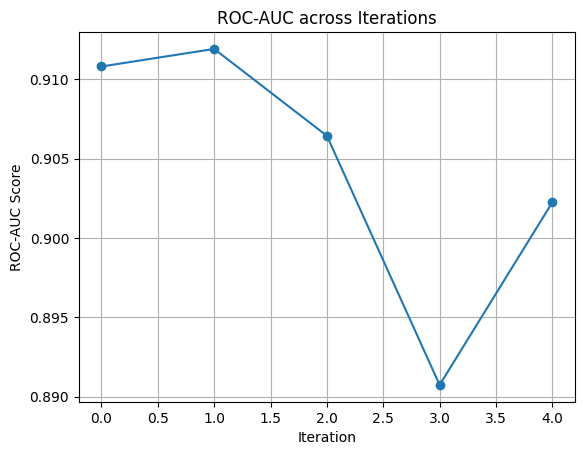

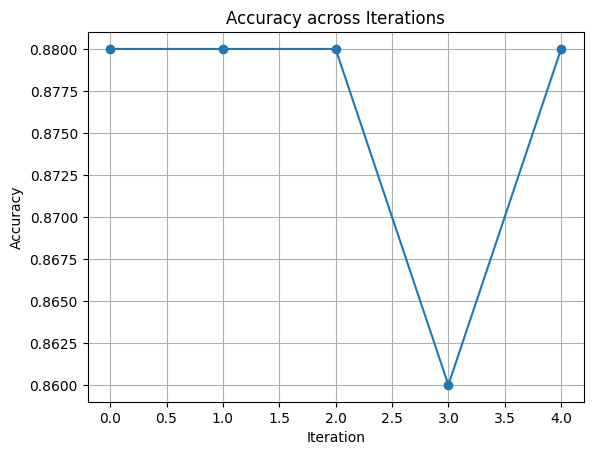

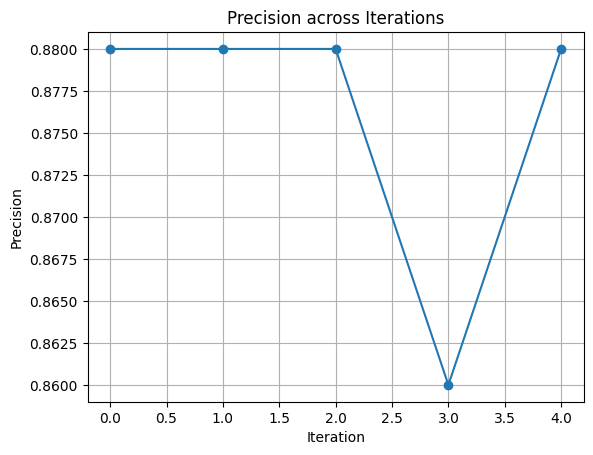

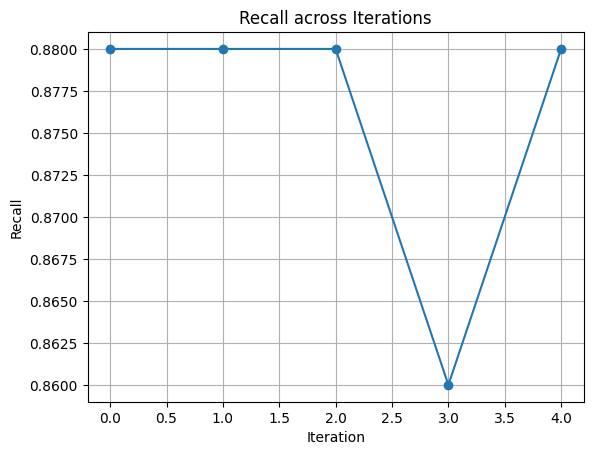

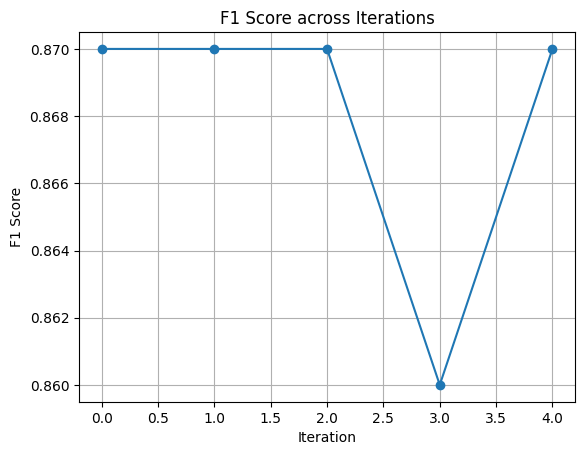

In [50]:
import json
import matplotlib.pyplot as plt

# Load JSON file
file_path = "iteration_logs1.json"

with open(file_path, "r") as f:
    data = json.load(f)

# If multiple JSON objects are stored separately, handle like this:
# data = []
# with open(file_path, "r") as f:
#     for line in f:
#         if line.strip():
#             data.append(json.loads(line))

iterations = []
roc_scores = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

print("\n===== CLASSIFICATION REPORTS =====\n")

for item in data:
    it = item["iteration"]
    roc = item["roc_auc"]
    report = item["classification_report"]
    
    acc, prec, rec, f1 = extract_metrics(report)
    
    iterations.append(it)
    roc_scores.append(roc)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)
    
    print(f"\n--- Iteration {it} ---")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1-score: {f1}")
    print(report)
    
# Plot ROC-AUC graph
plt.figure()
plt.plot(iterations, roc_scores, marker='o')
plt.xlabel("Iteration")
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC across Iterations")
plt.grid()

plt.show()

plt.figure()
plt.plot(iterations, accuracies, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, precisions, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Precision")
plt.title("Precision across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, recalls, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Recall")
plt.title("Recall across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, f1_scores, marker='o')
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.title("F1 Score across Iterations")
plt.grid()
plt.show()